In [1]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
from PIL import Image

from landmarks_path import landmarks, paths

In [2]:
alpha = 2.3 # fuel cost per km
beta = 4.6 # Time contribution coefficient

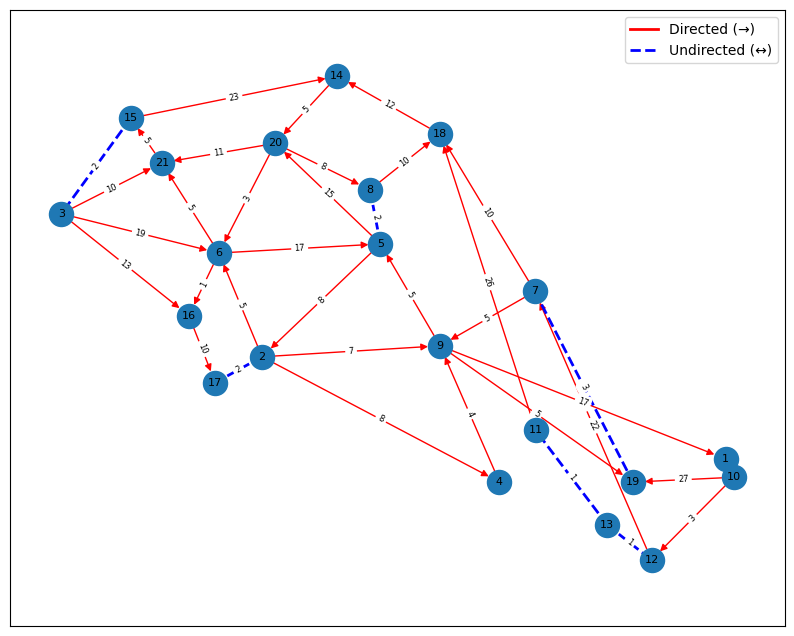

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))  # bigger canvas

# --- Create graphs ---
G_directed = nx.DiGraph()
G_undirected = nx.Graph()

for p in paths:
    a, b = p["node_a"], p["node_b"]
    omega = alpha * p["distance"] + beta * p["time"]
    weight = (1 + p["risk"] + p["traffic_congestion"]) * omega
    weight = round(weight)
    if p["is_directed"]:
        G_directed.add_edge(a, b, weight = weight)
    else:
        G_undirected.add_edge(a, b, weight = weight)

# --- Position from real coordinates ---
pos = {
    lm["id"]: (lm["longitude"], lm["latitude"])
    for lm in landmarks
}

# --- Combine graph for nodes ---
G_all = nx.compose(G_directed, G_undirected)

# --- Draw nodes ---
nx.draw_networkx_nodes(G_all, pos, node_size=300)

# --- Labels (use names instead of IDs) ---
labels = {lm["id"]: lm["id"] for lm in landmarks}
nx.draw_networkx_labels(G_all, pos, labels, font_size=8)

# --- Directed edges (red arrows) ---
nx.draw_networkx_edges(
    G_directed, pos,
    edge_color='red',
    arrows=True,
    arrowsize=10,
    width=1
)

# --- Undirected edges (blue dashed) ---
nx.draw_networkx_edges(
    G_undirected, pos,
    edge_color='blue',
    style='dashed',
    width=2
)


# --- Draw network edges weight ---

edge_labels_directed = nx.get_edge_attributes(G_directed, 'weight')
edge_labels_undirected = nx.get_edge_attributes(G_undirected, 'weight')

nx.draw_networkx_edge_labels(G_directed, pos, edge_labels=edge_labels_directed, font_size=6)
nx.draw_networkx_edge_labels(G_undirected, pos, edge_labels=edge_labels_undirected, font_size=6)

# Adjustment of graph visualisation
x_vals = [lm["longitude"] for lm in landmarks]
y_vals = [lm["latitude"] for lm in landmarks]

margin = 0.002  # adjust this

plt.xlim(min(x_vals) - margin, max(x_vals) + margin)
plt.ylim(min(y_vals) - margin, max(y_vals) + margin)

# plt.title("State space graph")
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Directed (→)'),
    Line2D([0], [0], color='blue', lw=2, linestyle='dashed', label='Undirected (↔)')
]

plt.legend(handles=legend_elements, loc='upper right')

plt.savefig("../Report/figures/state_space_graph.png", dpi=300, bbox_inches='tight')

plt.show()


In [4]:
len(paths)

37

In [5]:
G = nx.DiGraph()

for p in paths:
    a, b = p["node_a"], p["node_b"]

    G.add_edge(a, b)

    if not p["is_directed"]:
        G.add_edge(b, a)


print("Weakly connected:", nx.is_weakly_connected(G))
print("Strongly connected:", nx.is_strongly_connected(G))
print("Components:", list(nx.strongly_connected_components(G)))

Weakly connected: True
Strongly connected: True
Components: [{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21}]
